# Cross-cutting analysis for the thesis chapter

Loads the 5 CSV folders (small ViT main, small ViT grid, larger ViT main, larger ViT swaps=100, SmolLM2 main) into separate DataFrames so we can build cross-cutting figures without re-loading.

Folder layout assumed:

```
csvs_for_theses/
├── benchmark_csvs_smollm_HuggingFaceTB_SmolLM2-360M_full_sweep_dont_touch/
├── benchmark_csvs_vit_test_vit3.r160_in1k_full_grid_iters/
├── benchmark_csvs_vit_test_vit3.r160_in1k_full_sweep_dont_touch/
├── benchmark_csvs_vit_vit_wee_patch16_reg1_gap_256.sbb_in1k_100_swaps_tetris/
└── benchmark_csvs_vit_vit_wee_patch16_reg1_gap_256.sbb_in1k_full_sweep_dont_touch/
```

## Set up plotting and load CSVs

In [147]:
%load_ext autoreload
%autoreload 2

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = "."

FOLDER_VIT3_MAIN     = f"{ROOT}/benchmark_csvs_vit_test_vit3.r160_in1k_full_sweep_dont_touch"
FOLDER_VIT3_GRID     = f"{ROOT}/benchmark_csvs_vit_test_vit3.r160_in1k_full_grid_iters"
FOLDER_VITWEE_MAIN   = f"{ROOT}/benchmark_csvs_vit_vit_wee_patch16_reg1_gap_256.sbb_in1k_full_sweep_dont_touch"
FOLDER_VITWEE_SWAPS100 = f"{ROOT}/benchmark_csvs_vit_vit_wee_patch16_reg1_gap_256.sbb_in1k_100_swaps_tetris"
FOLDER_SMOLLM_MAIN   = f"{ROOT}/benchmark_csvs_smollm_HuggingFaceTB_SmolLM2-360M_full_sweep_dont_touch"
FOLDER_SMOLLM_135M   = f"{ROOT}/benchmark_csvs_smollm_HuggingFaceTB_SmolLM2-135M"


# Algorithm display name mapping
ALG_DISPLAY = {
    "our_tetris":                       "GA-TETRIS",
    "original_tetris":                  "Original TETRIS",
    "block_wanda":                      "Block-Wanda",
    "block_only":                       "Block-Wanda",
    "sort_columns_by_norm":             "Sort-by-Norm",
    "random_swaps":                     "Random-Swaps",
    "random_swaps_find_mask":           "Random-Swaps",
    "random_swaps_sort_start":          "Random-Swaps (sorted)",
    "random_swaps_find_mask_sort_start":"Random-Swaps (sorted)",
}

# Consistent colors per algorithm
ALG_COLORS = {
    "GA-TETRIS":             "#d62728",
    "Original TETRIS":       "#1f77b4",
    "Sort-by-Norm":          "#2ca02c",
    "Block-Wanda":           "#ff7f0e",
    "Random-Swaps":          "#8c564b",
    "Random-Swaps (sorted)": "#17becf",
}
def alg_color(a):
    return ALG_COLORS.get(a, "#555555")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [148]:
def _layer_parser(name):
    m = re.match(r"blocks\.(\d+)\.(.+)", name)
    return (None, name) if not m else (int(m.group(1)), m.group(2))


def load_folder(folder, infer_inner_refine=False):
    """Load all layer_metrics_*.csv files from a folder into a single DataFrame.
    
    If infer_inner_refine=True, parse INNER_REFINE from the filename (used for
    the GA-TETRIS grid sweep folder where INNER_REFINE varies).
    """
    files = sorted(glob.glob(os.path.join(folder, "layer_metrics_*.csv")))
    if not files:
        print(f"WARN: no CSVs in {folder}")
        return pd.DataFrame()
    
    frames = []
    for f in files:
        d = pd.read_csv(f)
        if infer_inner_refine:
            m = re.search(r"_innerref_(\d+)", os.path.basename(f))
            d["inner_refine"] = int(m.group(1)) if m else None
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    
    # Parse layer_idx and layer_type
    parsed = df["layer_name"].apply(_layer_parser)
    df["layer_idx"] = parsed.apply(lambda x: x[0])
    df["layer_type"] = parsed.apply(lambda x: x[1])
    df = df[df["layer_idx"].notna()].copy()
    df["layer_idx"] = df["layer_idx"].astype(int)
    
    # Promote sort_start variant
    if "sort_start" in df.columns:
        is_rs = df["algorithm"].isin(["random_swaps", "random_swaps_find_mask"])
        df.loc[is_rs & (df["sort_start"] == True), "algorithm"] = (
            df.loc[is_rs & (df["sort_start"] == True), "algorithm"] + "_sort_start"
        )
    
    # Map to display names
    df["algorithm"] = df["algorithm"].map(ALG_DISPLAY).fillna(df["algorithm"])
    
    return df


df_vit3_main      = load_folder(FOLDER_VIT3_MAIN)
df_vit3_grid      = load_folder(FOLDER_VIT3_GRID, infer_inner_refine=True)
df_vitwee_main    = load_folder(FOLDER_VITWEE_MAIN)
df_vitwee_swap100 = load_folder(FOLDER_VITWEE_SWAPS100)
df_smollm         = load_folder(FOLDER_SMOLLM_MAIN)
df_smollm_135m = load_folder(FOLDER_SMOLLM_135M)

print(f"vit3 main:        {len(df_vit3_main):>5} rows, algorithms: {sorted(df_vit3_main.algorithm.unique())}")
print(f"vit3 grid:        {len(df_vit3_grid):>5} rows")
print(f"vit-wee main:     {len(df_vitwee_main):>5} rows, algorithms: {sorted(df_vitwee_main.algorithm.unique())}")
print(f"vit-wee swap100:  {len(df_vitwee_swap100):>5} rows, algorithms: {sorted(df_vitwee_swap100.algorithm.unique())}")
print(f"smollm main:      {len(df_smollm):>5} rows, algorithms: {sorted(df_smollm.algorithm.unique())}")
print(f"smollm 135m:      {len(df_smollm_135m):>5} rows, algorithms: {sorted(df_smollm_135m.algorithm.unique())}")


vit3 main:         1116 rows, algorithms: ['Block-Wanda', 'GA-TETRIS', 'Original TETRIS', 'Random-Swaps', 'Random-Swaps (sorted)', 'Sort-by-Norm', 'no_prune']
vit3 grid:         3096 rows
vit-wee main:      1736 rows, algorithms: ['Block-Wanda', 'GA-TETRIS', 'Original TETRIS', 'Random-Swaps', 'Random-Swaps (sorted)', 'Sort-by-Norm', 'no_prune']
vit-wee swap100:    560 rows, algorithms: ['GA-TETRIS']
smollm main:       6720 rows, algorithms: ['Block-Wanda', 'GA-TETRIS', 'Original TETRIS', 'Random-Swaps', 'Random-Swaps (sorted)', 'Sort-by-Norm']
smollm 135m:       1260 rows, algorithms: ['Block-Wanda', 'GA-TETRIS', 'Original TETRIS', 'Random-Swaps', 'Random-Swaps (sorted)', 'Sort-by-Norm']


In [149]:
df_smollm_135m[df_smollm_135m.block_cols == 2].groupby("algorithm")["perplexity_all_layers"].first()

algorithm
Block-Wanda              253.527649
GA-TETRIS                157.053757
Original TETRIS          254.170868
Random-Swaps             170.462204
Random-Swaps (sorted)    230.061096
Sort-by-Norm             227.933594
Name: perplexity_all_layers, dtype: float64

## Save figs helper

In [150]:
import os
FIGURES_DIR = "../../thesis/images"
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save figure as PDF in the figures directory."""
    path = os.path.join(FIGURES_DIR, f"{name}.pdf")
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved {path}")

## Large ViT 100 swaps vs 10 swaps comparison

In [151]:
# Both swaps=10 and swaps=100 are now in df_vitwee_swap100
ga_all = df_vitwee_swap100[(df_vitwee_swap100.algorithm == "GA-TETRIS") &
                           (df_vitwee_swap100.sparsity == 0.5)].copy()

ga10  = ga_all[ga_all.random_swaps == 10].copy()
ga100 = ga_all[ga_all.random_swaps == 100].copy()


def aggregate(df):
    return (df.groupby("block_cols")
              [["score_improvement_pct", "total_time_sec"]]
              .mean()
              .reset_index()
              .sort_values("block_cols"))


agg10  = aggregate(ga10)
agg100 = aggregate(ga100)

print(f"swaps=10  rows: {len(ga10):>5}, block widths: {sorted(ga10.block_cols.unique())}")
print(f"swaps=100 rows: {len(ga100):>5}, block widths: {sorted(ga100.block_cols.unique())}")

print("\nBlock | score s10 | score s100 | gain (pp) | time s10 | time s100 | ratio")
print("-" * 75)
for bc in sorted(set(agg10.block_cols) & set(agg100.block_cols)):
    s10  = agg10[agg10.block_cols == bc].iloc[0]
    s100 = agg100[agg100.block_cols == bc].iloc[0]
    gain = s100.score_improvement_pct - s10.score_improvement_pct
    ratio = s100.total_time_sec / s10.total_time_sec
    print(f"1x{bc:<3} | {s10.score_improvement_pct:>7.2f}   | "
          f"{s100.score_improvement_pct:>7.2f}    | {gain:>+5.2f}    | "
          f"{s10.total_time_sec:>6.3f}   | {s100.total_time_sec:>6.3f}    | {ratio:>4.1f}x")

swaps=10  rows:   280, block widths: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32)]
swaps=100 rows:   280, block widths: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32)]

Block | score s10 | score s100 | gain (pp) | time s10 | time s100 | ratio
---------------------------------------------------------------------------
1x2   |    1.25   |    3.25    | +2.00    |  0.869   |  7.645    |  8.8x
1x4   |    4.19   |    7.13    | +2.93    |  2.038   | 17.861    |  8.8x
1x8   |   13.53   |   17.04    | +3.50    |  3.942   | 33.982    |  8.6x
1x16  |   26.43   |   28.41    | +1.98    |  5.492   | 45.921    |  8.4x
1x32  |   32.26   |   33.34    | +1.08    |  6.085   | 51.140    |  8.4x


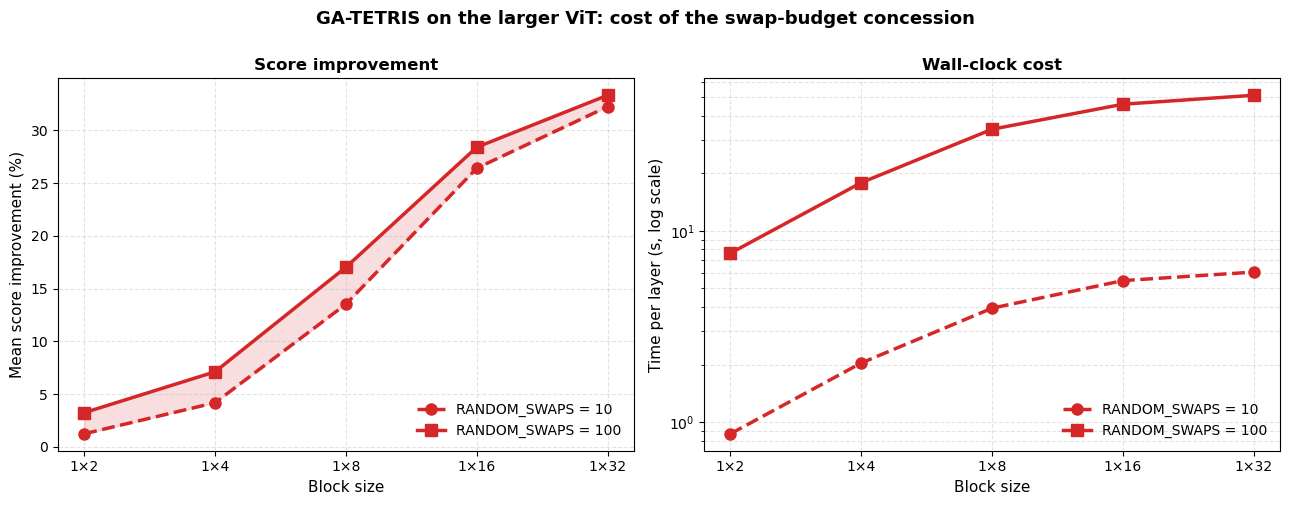

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

color = alg_color("GA-TETRIS")

# ----------------------------------------------------------------------------
# LEFT PANEL: score improvement
# ----------------------------------------------------------------------------
axes[0].plot(agg10.block_cols, agg10.score_improvement_pct,
             marker="o", linewidth=2.5, markersize=8, color=color,
             linestyle="--", label="RANDOM_SWAPS = 10")
axes[0].plot(agg100.block_cols, agg100.score_improvement_pct,
             marker="s", linewidth=2.5, markersize=8, color=color,
             linestyle="-", label="RANDOM_SWAPS = 100")

# Shade the gap between the curves
common_bcs = sorted(set(agg10.block_cols) & set(agg100.block_cols))
y10  = [agg10[agg10.block_cols == bc].iloc[0].score_improvement_pct for bc in common_bcs]
y100 = [agg100[agg100.block_cols == bc].iloc[0].score_improvement_pct for bc in common_bcs]
axes[0].fill_between(common_bcs, y10, y100, alpha=0.15, color=color)

axes[0].set_xscale("log", base=2)
axes[0].set_xticks(sorted(agg10.block_cols.unique()))
axes[0].set_xticklabels([f"1×{w}" for w in sorted(agg10.block_cols.unique())])
axes[0].set_xlabel("Block size", fontsize=11)
axes[0].set_ylabel("Mean score improvement (%)", fontsize=11)
axes[0].set_title("Score improvement", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].legend(frameon=False, fontsize=10, loc="lower right")

# ----------------------------------------------------------------------------
# RIGHT PANEL: time per layer (log y)
# ----------------------------------------------------------------------------
axes[1].plot(agg10.block_cols, agg10.total_time_sec,
             marker="o", linewidth=2.5, markersize=8, color=color,
             linestyle="--", label="RANDOM_SWAPS = 10")
axes[1].plot(agg100.block_cols, agg100.total_time_sec,
             marker="s", linewidth=2.5, markersize=8, color=color,
             linestyle="-", label="RANDOM_SWAPS = 100")

axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xticks(sorted(agg10.block_cols.unique()))
axes[1].set_xticklabels([f"1×{w}" for w in sorted(agg10.block_cols.unique())])
axes[1].set_xlabel("Block size", fontsize=11)
axes[1].set_ylabel("Time per layer (s, log scale)", fontsize=11)
axes[1].set_title("Wall-clock cost", fontsize=12, fontweight="bold")
axes[1].grid(True, which="both", linestyle="--", alpha=0.35)
axes[1].legend(frameon=False, fontsize=10, loc="lower right")

fig.suptitle("GA-TETRIS on the larger ViT: cost of the swap-budget concession",
             fontsize=13, fontweight="bold", y=1.00)
fig.tight_layout()
plt.show()


## Score improvement across all models and block widths

In [153]:
ALG_ORDER = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm",
             "Random-Swaps (sorted)", "Random-Swaps", "Block-Wanda"]


def heatmap_pivot(df, sparsity=0.5):
    """Build the (algorithm × block_width) score-improvement pivot for one model."""
    sub = df[df.sparsity == sparsity].copy()
    pivot = (sub.groupby(["algorithm", "block_cols"])["score_improvement_pct"]
                .mean()
                .unstack("block_cols"))
    rows = [a for a in ALG_ORDER if a in pivot.index]
    return pivot.loc[rows]


pivot_small  = heatmap_pivot(df_vit3_main)
pivot_larger = heatmap_pivot(df_vitwee_main)
pivot_smollm = heatmap_pivot(df_smollm)

panels = [
    ("Small ViT",  pivot_small),
    ("Larger ViT", pivot_larger),
    ("SmolLM2",    pivot_smollm),
]

all_values = np.concatenate([p.values.flatten() for _, p in panels])
vmin = float(np.nanmin(all_values))
vmax = float(np.nanmax(all_values))
vmax_abs = max(abs(vmin), abs(vmax))

print(f"Color range: [-{vmax_abs:.1f}, +{vmax_abs:.1f}]")
for name, p in panels:
    print(f"  {name}: min={p.values.min():.2f}, max={p.values.max():.2f}, shape={p.shape}")

Color range: [-33.6, +33.6]
  Small ViT: min=0.00, max=33.57, shape=(6, 5)
  Larger ViT: min=0.00, max=33.34, shape=(6, 5)
  SmolLM2: min=0.00, max=26.91, shape=(6, 5)


Saved ../../thesis/images/heatmap_score_improvement.pdf


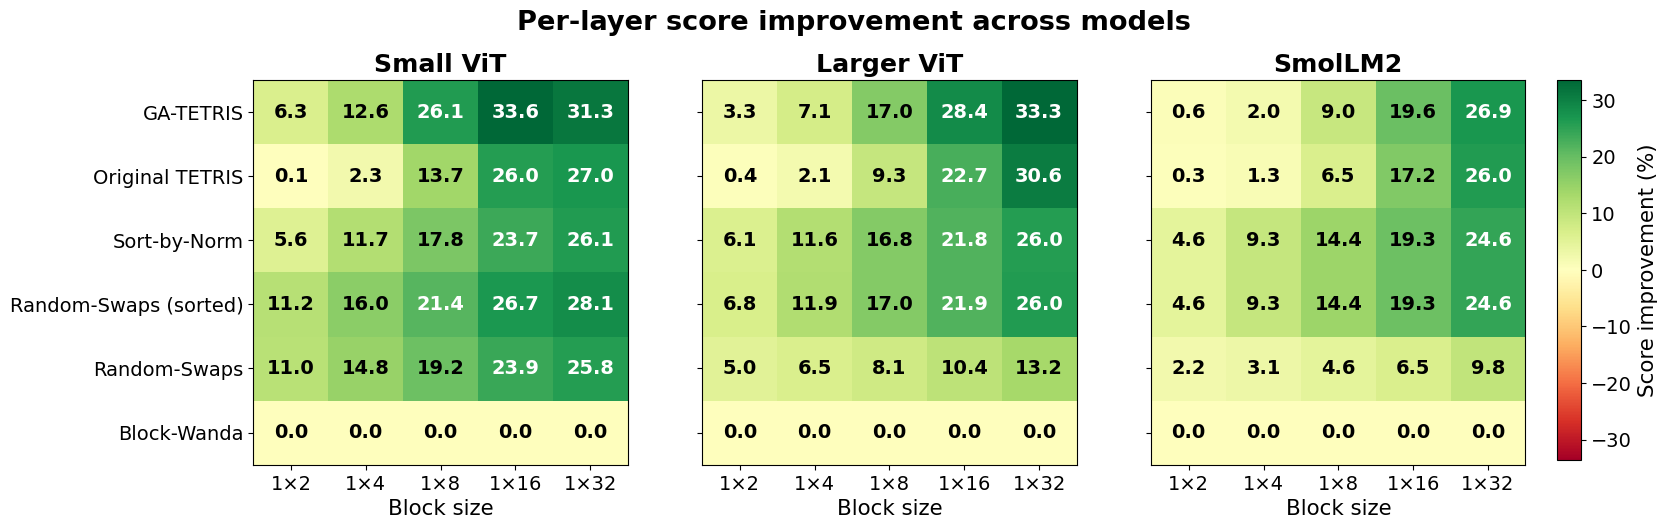

In [154]:
SCALE = 1.4  # for font size

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

ims = []
for ax, (model_name, pivot) in zip(axes, panels):
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn",
                   vmin=-vmax_abs, vmax=vmax_abs)
    ims.append(im)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            color = "white" if abs(v) > vmax_abs * 0.6 else "black"
            ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                    color=color, fontsize=10 * SCALE, fontweight="bold")

    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([f"1×{w}" for w in pivot.columns], fontsize=10 * SCALE)
    ax.set_xlabel("Block size", fontsize=11 * SCALE)
    ax.set_title(model_name, fontsize=13 * SCALE, fontweight="bold")

axes[0].set_yticks(range(pivot_small.shape[0]))
axes[0].set_yticklabels(pivot_small.index, fontsize=10 * SCALE)

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.12, 0.015, 0.76])
cbar = fig.colorbar(ims[0], cax=cbar_ax)
cbar.set_label("Score improvement (%)", fontsize=11 * SCALE)
cbar.ax.tick_params(labelsize=10 * SCALE)

fig.suptitle("Per-layer score improvement across models",
             fontsize=14 * SCALE, fontweight="bold", y=1.02)
save_fig(fig, "heatmap_score_improvement")
plt.show()

## Line graph score improvement comparison of selected algorithms

In [155]:
LINE_ALGS = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm"]

def line_data(df, sparsity=0.5):
    return (df[(df.algorithm.isin(LINE_ALGS)) & (df.sparsity == sparsity)]
            .groupby(["algorithm", "block_cols"])["score_improvement_pct"]
            .mean()
            .reset_index())

ld_small  = line_data(df_vit3_main)
ld_larger = line_data(df_vitwee_main)
ld_smollm = line_data(df_smollm)

print("Small ViT:")
print(ld_small.pivot(index="algorithm", columns="block_cols", values="score_improvement_pct"))
print("\nLarger ViT:")
print(ld_larger.pivot(index="algorithm", columns="block_cols", values="score_improvement_pct"))
print("\nSmolLM2:")
print(ld_smollm.pivot(index="algorithm", columns="block_cols", values="score_improvement_pct"))

Small ViT:
block_cols             2          4          8          16         32
algorithm                                                            
GA-TETRIS        6.302997  12.579314  26.079459  33.571494  31.319718
Original TETRIS  0.078819   2.290139  13.732354  25.953592  26.980382
Sort-by-Norm     5.615642  11.730577  17.823824  23.660319  26.137311

Larger ViT:
block_cols             2          4          8          16         32
algorithm                                                            
GA-TETRIS        3.252367   7.126711  17.036706  28.411231  33.339829
Original TETRIS  0.406253   2.096166   9.303676  22.726839  30.637219
Sort-by-Norm     6.127379  11.596658  16.804729  21.782433  25.963329

SmolLM2:
block_cols             2         4          8          16         32
algorithm                                                           
GA-TETRIS        0.551938  2.002981   9.026719  19.563632  26.906522
Original TETRIS  0.321838  1.305613   6.455081  17.181087  

Saved ../../thesis/images/line_score_improvement.pdf


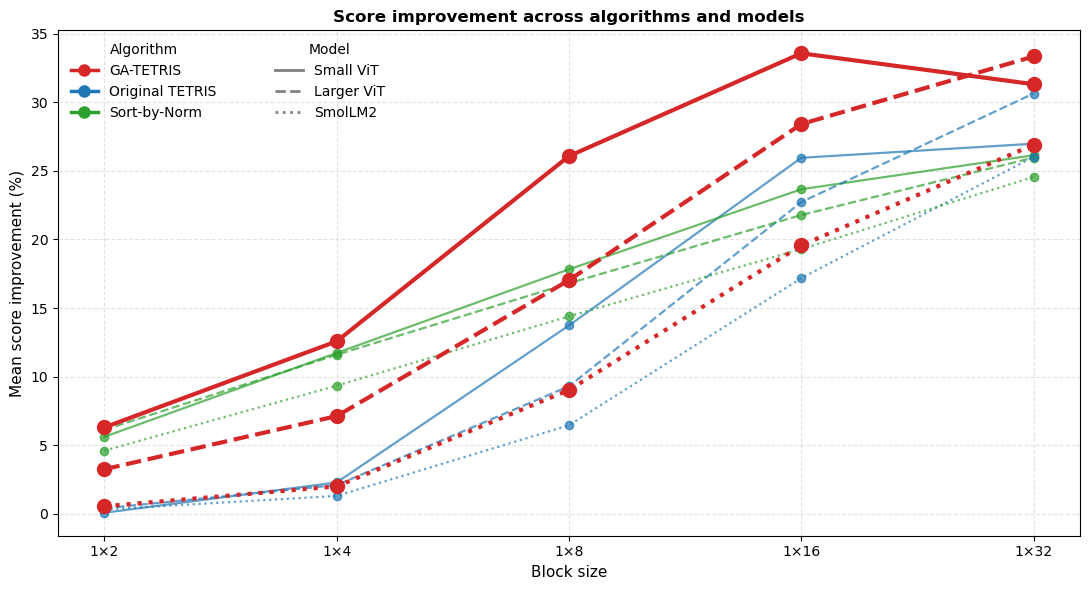

In [156]:
from matplotlib.lines import Line2D

MODEL_STYLES = {"Small ViT": "-", "Larger ViT": "--", "SmolLM2": ":"}

LEGEND_ALG_ORDER = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm"]
LEGEND_MODEL_ORDER = ["Small ViT", "Larger ViT", "SmolLM2"]


def line_kwargs(alg, model):
    style = MODEL_STYLES[model]
    if alg == "GA-TETRIS":
        return dict(linewidth=3.0, markersize=10, alpha=1.0, linestyle=style)
    return dict(linewidth=1.6, markersize=6, alpha=0.7, linestyle=style)


fig, ax = plt.subplots(figsize=(11, 6))

plot_order = []
for model_label, ld in [("Small ViT",  ld_small),
                        ("Larger ViT", ld_larger),
                        ("SmolLM2",    ld_smollm)]:
    for alg in LEGEND_ALG_ORDER:
        sub = ld[ld.algorithm == alg].sort_values("block_cols")
        plot_order.append((alg, model_label, sub))

plot_order.sort(key=lambda x: 1 if x[0] == "GA-TETRIS" else 0)

for alg, model_label, sub in plot_order:
    if len(sub) == 0:
        continue
    kwargs = line_kwargs(alg, model_label)
    ax.plot(sub.block_cols, sub.score_improvement_pct,
            marker="o", color=alg_color(alg), **kwargs)

alg_handles = [
    Line2D([0], [0], color=alg_color(alg), linewidth=2.5,
           marker="o", markersize=8, label=alg)
    for alg in LEGEND_ALG_ORDER
]
model_handles = [
    Line2D([0], [0], color="gray", linewidth=2,
           linestyle=MODEL_STYLES[m], label=m)
    for m in LEGEND_MODEL_ORDER
]

leg1 = ax.legend(handles=alg_handles, loc="upper left",
                 frameon=False, fontsize=10, title="Algorithm")
ax.add_artist(leg1)
ax.legend(handles=model_handles, loc="upper left",
          bbox_to_anchor=(0.20, 1.0),
          frameon=False, fontsize=10, title="Model")

ax.set_xscale("log", base=2)
block_widths = sorted(ld_small.block_cols.unique())
ax.set_xticks(block_widths)
ax.set_xticklabels([f"1×{w}" for w in block_widths])
ax.set_xlabel("Block size", fontsize=11)
ax.set_ylabel("Mean score improvement (%)", fontsize=11)
ax.set_title("Score improvement across algorithms and models",
             fontsize=12, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.35)
fig.tight_layout()
save_fig(fig, "line_score_improvement")
plt.show()

## Per transformer block score improvement

Saved ../../thesis/images/per_block_score_improvement.pdf


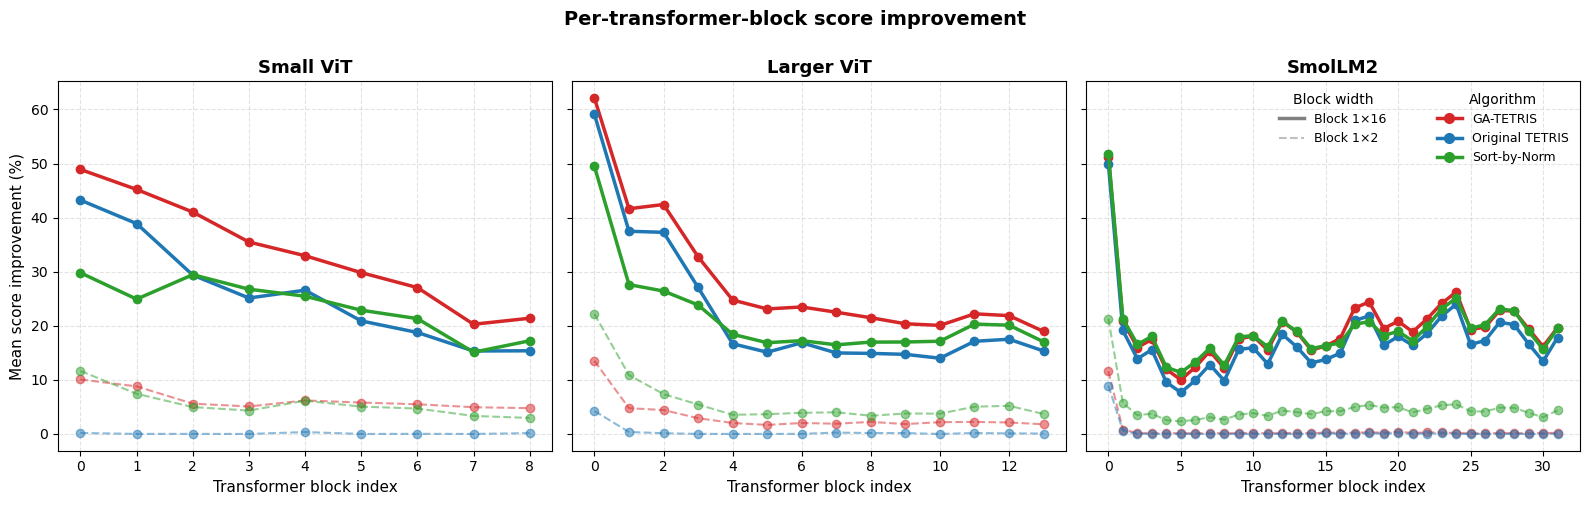

In [157]:
PER_BLOCK_NARROW = 2
PER_BLOCK_WIDE   = 16
PER_BLOCK_ALGS = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm"]


def per_block_data(df, block_w, sparsity=0.5):
    sub = df[(df.sparsity == sparsity) &
             (df.block_cols == block_w) &
             (df.algorithm.isin(PER_BLOCK_ALGS))]
    return (sub.groupby(["algorithm", "layer_idx"])
              ["score_improvement_pct"]
              .mean()
              .reset_index())


pb_data = {
    "Small ViT": {
        PER_BLOCK_NARROW: per_block_data(df_vit3_main, PER_BLOCK_NARROW),
        PER_BLOCK_WIDE:   per_block_data(df_vit3_main, PER_BLOCK_WIDE),
    },
    "Larger ViT": {
        PER_BLOCK_NARROW: per_block_data(df_vitwee_main, PER_BLOCK_NARROW),
        PER_BLOCK_WIDE:   per_block_data(df_vitwee_main, PER_BLOCK_WIDE),
    },
    "SmolLM2": {
        PER_BLOCK_NARROW: per_block_data(df_smollm, PER_BLOCK_NARROW),
        PER_BLOCK_WIDE:   per_block_data(df_smollm, PER_BLOCK_WIDE),
    },
}


from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, model_name in zip(axes, ["Small ViT", "Larger ViT", "SmolLM2"]):
    for block_w, linestyle, alpha, lw in [(PER_BLOCK_WIDE, "-", 1.0, 2.5),
                                          (PER_BLOCK_NARROW, "--", 0.5, 1.5)]:
        pb = pb_data[model_name][block_w]
        for alg in PER_BLOCK_ALGS:
            df_a = pb[pb.algorithm == alg].sort_values("layer_idx")
            if len(df_a) == 0:
                continue
            ax.plot(df_a.layer_idx, df_a.score_improvement_pct,
                    marker="o", linewidth=lw, markersize=6,
                    color=alg_color(alg), linestyle=linestyle, alpha=alpha)

    ax.set_xlabel("Transformer block index", fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.35)

axes[0].set_ylabel("Mean score improvement (%)", fontsize=11)

# Legend: algorithm by color, block width by linestyle
alg_handles = [
    Line2D([0], [0], color=alg_color(a), linewidth=2.5, marker="o", markersize=7, label=a)
    for a in PER_BLOCK_ALGS
]
width_handles = [
    Line2D([0], [0], color="gray", linewidth=2.5, linestyle="-",  label=f"Block 1×{PER_BLOCK_WIDE}"),
    Line2D([0], [0], color="gray", linewidth=1.5, linestyle="--", alpha=0.5, label=f"Block 1×{PER_BLOCK_NARROW}"),
]
leg1 = axes[2].legend(handles=alg_handles, loc="upper right",
                      frameon=False, fontsize=9, title="Algorithm")
axes[2].add_artist(leg1)
axes[2].legend(handles=width_handles, loc="upper center",
               frameon=False, fontsize=9, title="Block width")

fig.suptitle(f"Per-transformer-block score improvement",
             fontsize=14, fontweight="bold", y=1.00)
fig.tight_layout()
save_fig(fig, "per_block_score_improvement")
plt.show()

## Rel error swarm at selected block sizes

Saved ../../thesis/images/swarm_rel_error_deltas.pdf


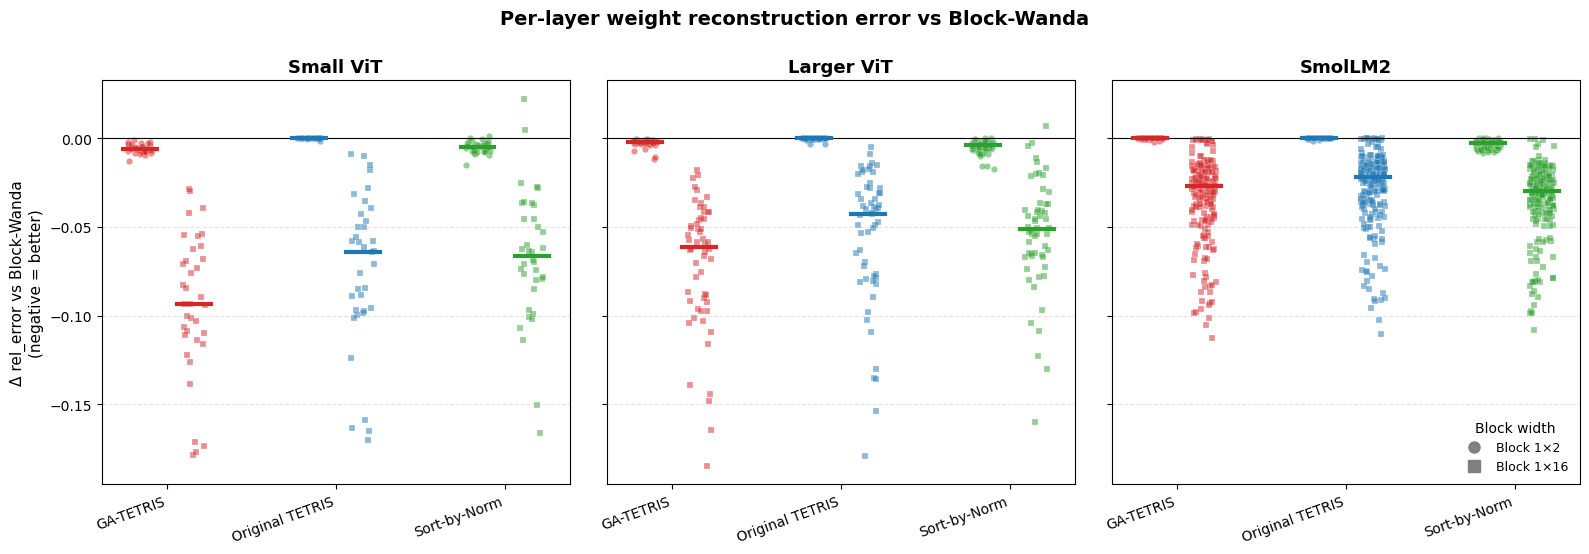

In [158]:
SWARM_NARROW_W = 2
SWARM_WIDE_W   = 16
SWARM_BASELINE = "Block-Wanda"
SWARM_ALGS = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm"]


def rel_error_deltas(df, block_w, baseline_alg, algs, sparsity=0.5):
    sub = df[(df.sparsity == sparsity) & (df.block_cols == block_w)].copy()
    if baseline_alg not in sub.algorithm.unique():
        return pd.DataFrame()

    base_ref = (sub[sub.algorithm == baseline_alg]
                .set_index(["layer_type", "layer_idx"])["rel_error"])

    rows = []
    for alg in algs:
        a_sub = sub[sub.algorithm == alg].set_index(["layer_type", "layer_idx"])
        for (lt, li), row in a_sub.iterrows():
            if (lt, li) not in base_ref.index:
                continue
            rows.append({
                "algorithm": alg,
                "block_w": block_w,
                "rel_error_delta": row["rel_error"] - base_ref[(lt, li)],
            })
    return pd.DataFrame(rows)


swarm_data = {}
for model_name, df in [("Small ViT", df_vit3_main),
                       ("Larger ViT", df_vitwee_main),
                       ("SmolLM2", df_smollm)]:
    narrow = rel_error_deltas(df, SWARM_NARROW_W, SWARM_BASELINE, SWARM_ALGS)
    wide   = rel_error_deltas(df, SWARM_WIDE_W,   SWARM_BASELINE, SWARM_ALGS)
    swarm_data[model_name] = pd.concat([narrow, wide], ignore_index=True)


fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
rng = np.random.default_rng(0)

# Within each panel, x-position is computed as: alg_index * 2.5 + width_offset
# Narrow at -0.4, Wide at +0.4 within each algorithm group
WIDTH_OFFSETS = {SWARM_NARROW_W: -0.4, SWARM_WIDE_W: +0.4}
WIDTH_MARKERS = {SWARM_NARROW_W: "o", SWARM_WIDE_W: "s"}
WIDTH_ALPHA   = {SWARM_NARROW_W: 0.5, SWARM_WIDE_W: 0.5}

for ax, (model_name, comp) in zip(axes, swarm_data.items()):
    if len(comp) == 0:
        ax.text(0.5, 0.5, "no data", ha="center", va="center",
                transform=ax.transAxes, color="gray")
        ax.set_title(model_name, fontsize=13, fontweight="bold")
        continue

    for i, alg in enumerate(SWARM_ALGS):
        for bw in [SWARM_NARROW_W, SWARM_WIDE_W]:
            s = comp[(comp.algorithm == alg) & (comp.block_w == bw)]
            if len(s) == 0:
                continue
            x_center = i * 2.5 + WIDTH_OFFSETS[bw]
            x = x_center + rng.uniform(-0.18, 0.18, size=len(s))
            ax.scatter(x, s["rel_error_delta"],
                color=alg_color(alg), s=22, alpha=WIDTH_ALPHA[bw],
                marker=WIDTH_MARKERS[bw],
                edgecolor="white", linewidth=0.3)
            med = s["rel_error_delta"].median()
            ax.plot([x_center - 0.25, x_center + 0.25], [med, med],
                    color=alg_color(alg), linewidth=3.0, zorder=5)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks([i * 2.5 for i in range(len(SWARM_ALGS))])
    ax.set_xticklabels(SWARM_ALGS, rotation=20, ha="right")
    ax.set_title(model_name, fontsize=13, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

axes[0].set_ylabel(f"Δ rel_error vs {SWARM_BASELINE}\n(negative = better)", fontsize=11)

# Legend for the two block widths
from matplotlib.lines import Line2D
width_handles = [
    Line2D([0], [0], marker=WIDTH_MARKERS[SWARM_NARROW_W], color="gray", markersize=8,
           markerfacecolor="gray", linestyle="", label=f"Block 1×{SWARM_NARROW_W}"),
    Line2D([0], [0], marker=WIDTH_MARKERS[SWARM_WIDE_W], color="gray", markersize=8,
           markerfacecolor="gray", linestyle="", label=f"Block 1×{SWARM_WIDE_W}"),
]
axes[2].legend(handles=width_handles, loc="lower right",
               frameon=False, fontsize=9, title="Block width")

fig.suptitle(f"Per-layer weight reconstruction error vs {SWARM_BASELINE}",
             fontsize=14, fontweight="bold", y=1.00)
fig.tight_layout()
save_fig(fig, "swarm_rel_error_deltas")
plt.show()

## Time per layer

In [159]:
TIME_BLOCK_WIDTHS = [2, 16, 32]
TIME_ALGS = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm",
             "Random-Swaps (sorted)", "Random-Swaps", "Block-Wanda"]


def mean_time(df, alg, block_w, sparsity=0.5):
    sub = df[(df.algorithm == alg) &
             (df.block_cols == block_w) &
             (df.sparsity == sparsity)]
    if len(sub) == 0:
        return None
    return sub["total_time_sec"].mean()


rows = []
for alg in TIME_ALGS:
    for bw in TIME_BLOCK_WIDTHS:
        rows.append({
            "Algorithm": alg,
            "Block": f"1×{bw}",
            "Small ViT":   mean_time(df_vit3_main,   alg, bw),
            "Larger ViT":  mean_time(df_vitwee_main, alg, bw),
            "SmolLM2":     mean_time(df_smollm,      alg, bw),
        })

time_df = pd.DataFrame(rows)
print(f"\n=== Mean time per layer (seconds) ===\n")
print(time_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== Mean time per layer (seconds) ===

            Algorithm Block  Small ViT  Larger ViT  SmolLM2
            GA-TETRIS   1×2     0.2514      7.6451   2.5267
            GA-TETRIS  1×16     0.3949     45.9210  36.5668
            GA-TETRIS  1×32     0.3903     51.1402  42.2862
      Original TETRIS   1×2     0.0096      0.0115   0.0500
      Original TETRIS  1×16     0.0274      0.1676   1.7059
      Original TETRIS  1×32     0.0287      0.2313   0.7187
         Sort-by-Norm   1×2     0.0014      0.0015   0.0018
         Sort-by-Norm  1×16     0.0015      0.0015   0.0067
         Sort-by-Norm  1×32     0.0014      0.0015   0.0018
Random-Swaps (sorted)   1×2     0.8679      2.2344   7.4447
Random-Swaps (sorted)  1×16     0.8704      2.2578   7.1431
Random-Swaps (sorted)  1×32     0.9000      2.2850   7.1235
         Random-Swaps   1×2     0.8529      2.3014   7.3233
         Random-Swaps  1×16     0.8580      2.2813   7.1701
         Random-Swaps  1×32     0.8603      2.2727   7.1871


# Whole model comparisons

Saved ../../thesis/images/whole_model_performance.pdf


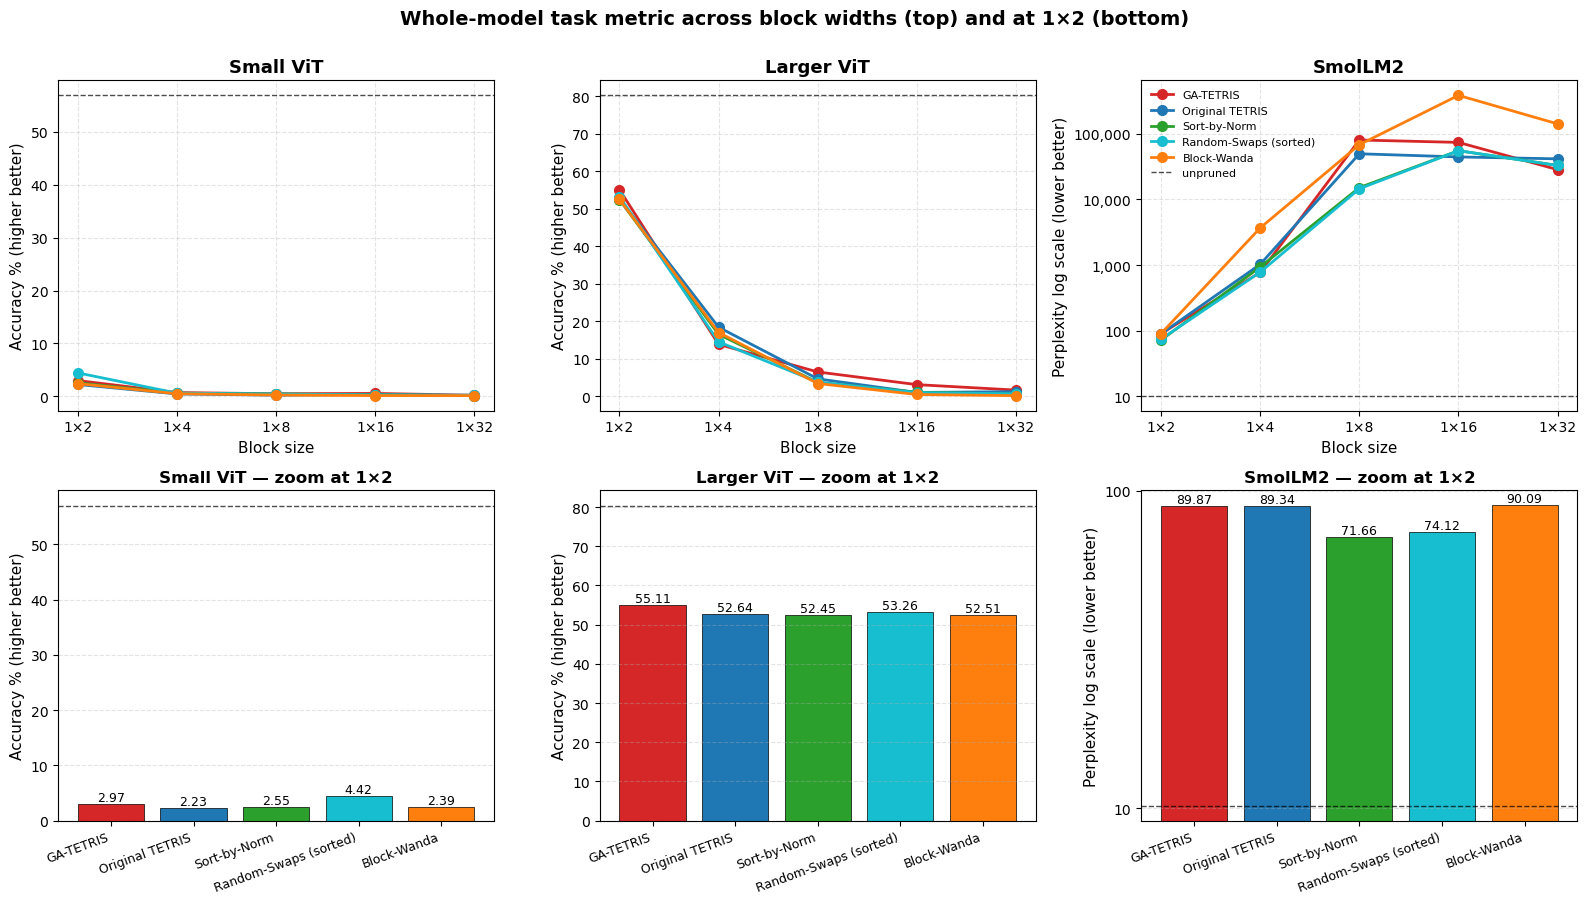

In [160]:
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker

ALGS_FOR_PLOT = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm",
                 "Random-Swaps (sorted)", "Block-Wanda"]


def whole_model_data(df, metric_col, sparsity=0.5, scale=1.0):
    sub = df[df.sparsity == sparsity]
    out = (sub.groupby(["algorithm", "block_cols"])[metric_col]
              .first()
              .reset_index()
              .rename(columns={metric_col: "metric"}))
    out["metric"] = out["metric"] * scale
    return out


def baseline_value(df, metric_col, scale=1.0):
    sub = df[df[metric_col].notna()]
    if "no_prune" in sub.algorithm.unique():
        v = sub[sub.algorithm == "no_prune"][metric_col].iloc[0]
        return v * scale
    base_col = metric_col.replace("_all_layers", "_baseline")
    if base_col in sub.columns and sub[base_col].notna().any():
        return sub[base_col].dropna().iloc[0] * scale
    return None


cliff_panels = [
    ("Small ViT",  whole_model_data(df_vit3_main,   "accuracy_all_layers", scale=100),
     baseline_value(df_vit3_main, "accuracy_all_layers", scale=100),
     "Accuracy % (higher better)", False),
    ("Larger ViT", whole_model_data(df_vitwee_main, "accuracy_all_layers", scale=100),
     baseline_value(df_vitwee_main, "accuracy_all_layers", scale=100),
     "Accuracy % (higher better)", False),
    ("SmolLM2",    whole_model_data(df_smollm,      "perplexity_all_layers"),
     baseline_value(df_smollm, "perplexity_all_layers"),
     "Perplexity log scale (lower better)", True),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# === TOP ROW: full sweep ===
for ax, (model_name, df, baseline, ylabel, log_y) in zip(axes[0], cliff_panels):
    for alg in ALGS_FOR_PLOT:
        sub = df[df.algorithm == alg].sort_values("block_cols")
        if len(sub) == 0:
            continue
        ax.plot(sub.block_cols, sub.metric, marker="o", linewidth=2,
                markersize=7, color=alg_color(alg), label=alg)

    if baseline is not None:
        ax.axhline(baseline, color="black", linestyle="--", linewidth=1.0,
                   alpha=0.7, label=f"unpruned")

    ax.set_xscale("log", base=2)
    ax.set_xticks([2, 4, 8, 16, 32])
    ax.set_xticklabels([f"1×{w}" for w in [2, 4, 8, 16, 32]])
    if log_y:
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=[1.0]))
        ax.yaxis.set_minor_locator(mticker.NullLocator())
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
    ax.set_xlabel("Block size", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight="bold")
    ax.grid(True, which="both", linestyle="--", alpha=0.35)

axes[0, 2].legend(frameon=False, fontsize=8, loc="upper left")

# === BOTTOM ROW: zoom at 1×2 ===
for ax, (model_name, df, baseline, ylabel, log_y) in zip(axes[1], cliff_panels):
    sub = df[df.block_cols == 2].set_index("algorithm")
    algs_present = [a for a in ALGS_FOR_PLOT if a in sub.index]
    values = [sub.loc[a, "metric"] for a in algs_present]
    colors = [alg_color(a) for a in algs_present]

    bars = ax.bar(range(len(algs_present)), values, color=colors,
                  edgecolor="black", linewidth=0.5)

    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)

    if baseline is not None:
        ax.axhline(baseline, color="black", linestyle="--", linewidth=1.0,
                   alpha=0.7, label=f"unpruned")

    if log_y:
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=[1.0]))
        ax.yaxis.set_minor_locator(mticker.NullLocator())
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
    ax.set_xticks(range(len(algs_present)))
    ax.set_xticklabels(algs_present, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"{model_name} — zoom at 1×2", fontsize=12, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

fig.suptitle("Whole-model task metric across block widths (top) and at 1×2 (bottom)",
             fontsize=14, fontweight="bold", y=1.00)
fig.tight_layout()
save_fig(fig, "whole_model_performance")
plt.show()

Saved ../../thesis/images/per_layer_type_score_improvement.pdf


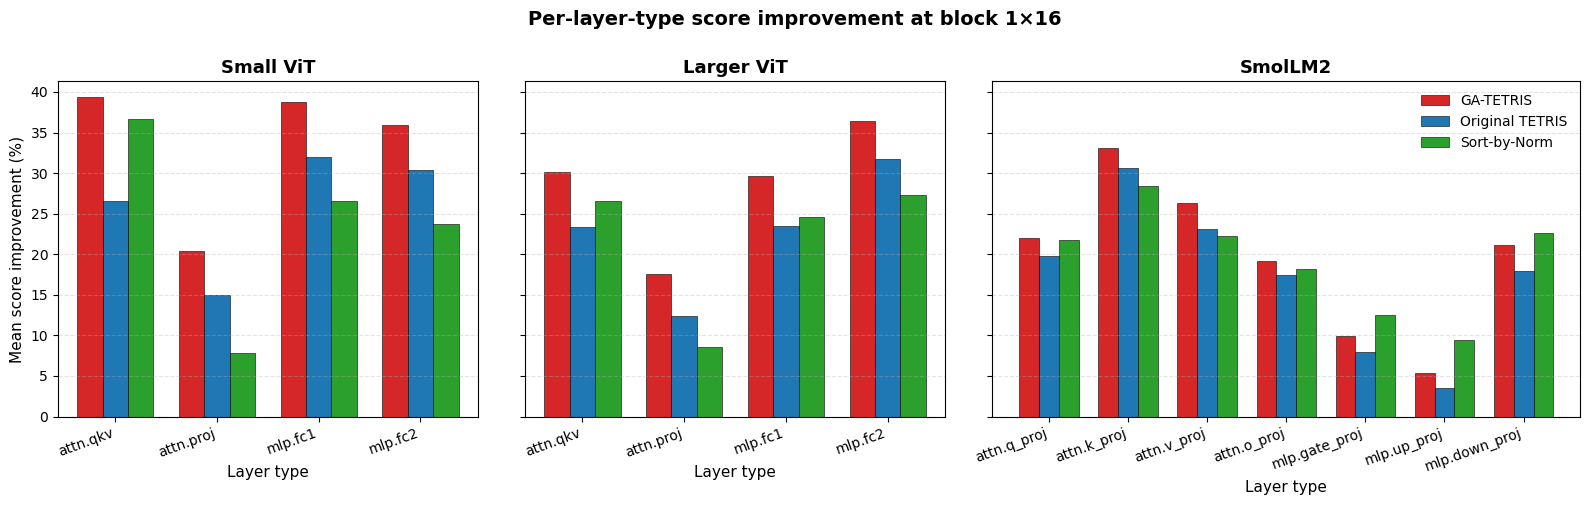

In [161]:
LAYER_TYPE_BLOCK_W = 16
LAYER_TYPE_ALGS = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm"]

VIT_LAYER_ORDER = ["attn.qkv", "attn.proj", "mlp.fc1", "mlp.fc2"]
SMOLLM_LAYER_ORDER = ["self_attn.q_proj", "self_attn.k_proj",
                      "self_attn.v_proj", "self_attn.o_proj",
                      "mlp.gate_proj", "mlp.up_proj", "mlp.down_proj"]


def per_layer_type_data(df, block_w, layer_order, sparsity=0.5):
    sub = df[(df.sparsity == sparsity) &
             (df.block_cols == block_w) &
             (df.algorithm.isin(LAYER_TYPE_ALGS))]
    pivot = (sub.groupby(["algorithm", "layer_type"])["score_improvement_pct"]
                .mean()
                .unstack("layer_type"))
    cols = [c for c in layer_order if c in pivot.columns]
    return pivot[cols]


lt_small  = per_layer_type_data(df_vit3_main,   LAYER_TYPE_BLOCK_W, VIT_LAYER_ORDER)
lt_larger = per_layer_type_data(df_vitwee_main, LAYER_TYPE_BLOCK_W, VIT_LAYER_ORDER)
lt_smollm = per_layer_type_data(df_smollm,      LAYER_TYPE_BLOCK_W, SMOLLM_LAYER_ORDER)


fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1, 1.4]}, sharey=True)

panels = [
    ("Small ViT",  lt_small),
    ("Larger ViT", lt_larger),
    ("SmolLM2",    lt_smollm),
]

bar_width = 0.25

for ax, (model_name, pivot) in zip(axes, panels):
    layer_types = list(pivot.columns)
    n_algs = len(LAYER_TYPE_ALGS)
    x = np.arange(len(layer_types))

    for i, alg in enumerate(LAYER_TYPE_ALGS):
        if alg not in pivot.index:
            continue
        offset = (i - (n_algs - 1) / 2) * bar_width
        ax.bar(x + offset, pivot.loc[alg].values, bar_width,
               color=alg_color(alg), label=alg, edgecolor="black", linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels([t.replace("self_attn.", "attn.") for t in layer_types], rotation=20, ha="right", fontsize=10)
    ax.set_xlabel("Layer type", fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.axhline(0, color="black", linewidth=0.6)

axes[0].set_ylabel("Mean score improvement (%)", fontsize=11)
axes[2].legend(frameon=False, fontsize=10, loc="best")

fig.suptitle(f"Per-layer-type score improvement at block 1×{LAYER_TYPE_BLOCK_W}",
             fontsize=14, fontweight="bold", y=1.00)
fig.tight_layout()
save_fig(fig, "per_layer_type_score_improvement")
plt.show()

Saved ../../thesis/images/smollm_135m_block1x2.pdf


/var/folders/ln/fhk1_2pd10n5h6m_z3xbszwm0000gn/T/ipykernel_64159/3260352109.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=9, loc="lower right")


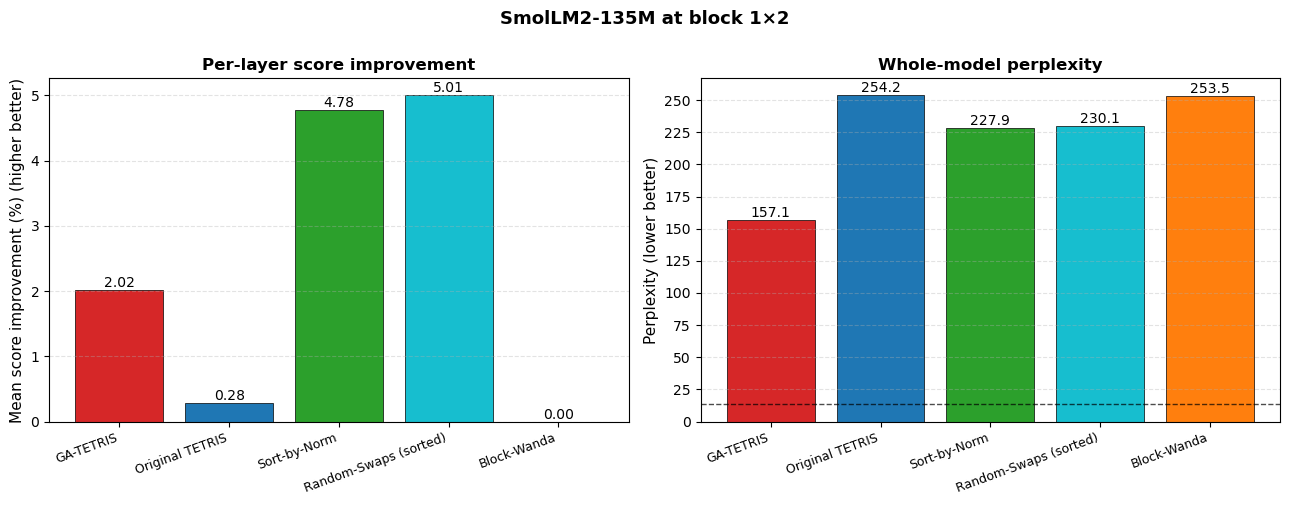


=== SmolLM2-135M at block 1×2 ===
Algorithm                   Score impr. (%)   Perplexity
--------------------------------------------------------
GA-TETRIS                              2.02       157.05
Original TETRIS                        0.28       254.17
Sort-by-Norm                           4.78       227.93
Random-Swaps (sorted)                  5.01       230.06
Block-Wanda                            0.00       253.53
unpruned                                  —        13.62


In [169]:
# =============================================================================
# SmolLM2-135M at block 1x2: score improvement and perplexity across algorithms
# =============================================================================

from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker

ALGS_135M = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm",
             "Random-Swaps (sorted)", "Block-Wanda"]
BLOCK_W = 2
SPARSITY = 0.5

df = df_smollm_135m

# Score improvement: mean across layers, per algorithm
score_vals = []
for alg in ALGS_135M:
    sub = df[(df.algorithm == alg) & (df.block_cols == BLOCK_W) & (df.sparsity == SPARSITY)]
    score_vals.append(sub["score_improvement_pct"].mean() if len(sub) else np.nan)

# Whole-model perplexity per algorithm
perp_map = (df[(df.sparsity == SPARSITY) & (df.block_cols == BLOCK_W)]
              .groupby("algorithm")["perplexity_all_layers"].first().to_dict())
perp_vals = [perp_map.get(a, np.nan) for a in ALGS_135M]

unpruned = baseline_value(df, "perplexity_all_layers")

# ---- figure -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = [alg_color(a) for a in ALGS_135M]
x = np.arange(len(ALGS_135M))

# LEFT: per-layer score improvement
ax = axes[0]
bars = ax.bar(x, score_vals, color=colors, edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, score_vals):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(ALGS_135M, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Mean score improvement (%) (higher better)", fontsize=11)
ax.set_title("Per-layer score improvement", fontsize=12, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

# RIGHT: whole-model perplexity
ax = axes[1]
bars = ax.bar(x, perp_vals, color=colors, edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, perp_vals):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f"{v:.1f}", ha="center", va="bottom", fontsize=10)

if unpruned is not None:
    ax.axhline(unpruned, color="black", linestyle="--", linewidth=1.0,
               alpha=0.7)
    ax.legend(frameon=False, fontsize=9, loc="lower right")

ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
ax.set_xticks(x)
ax.set_xticklabels(ALGS_135M, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Perplexity (lower better)", fontsize=11)
ax.set_title("Whole-model perplexity", fontsize=12, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

fig.suptitle("SmolLM2-135M at block 1×2", fontsize=13, fontweight="bold", y=1.00)
fig.tight_layout()
save_fig(fig, "smollm_135m_block1x2")
plt.show()

# ---- numerical summary ------------------------------------------------------
print(f"\n=== SmolLM2-135M at block 1×{BLOCK_W} ===")
print(f"{'Algorithm':<25} {'Score impr. (%)':>17} {'Perplexity':>12}")
print("-" * 56)
for alg, s, p in zip(ALGS_135M, score_vals, perp_vals):
    s_str = f"{s:.2f}" if not np.isnan(s) else "—"
    p_str = f"{p:.2f}" if (p is not None and not np.isnan(p)) else "—"
    print(f"{alg:<25} {s_str:>17} {p_str:>12}")
if unpruned is not None:
    print(f"{'unpruned':<25} {'—':>17} {unpruned:>12.2f}")